# Phase 6 — Live Transaction Simulation
## Adaptive Real-Time Financial Transaction Fraud Detection System

**Notebook:** `notebooks/06_live_transaction_simulation.ipynb`
**Requires:** the Phase 5 FastAPI service (`src/api/app.py`) already **running** at `http://127.0.0.1:8000` before this notebook is executed.
**Reads:** `../data/raw/PS_20174392719_1491204439457_log.csv`, `../models/model_v1_metadata.json`
**Writes (under the existing `../reports/`):** `live_prediction_log.csv`, `delayed_ground_truth.csv`, `live_prediction_with_ground_truth.csv`, `live_transaction_type_summary.csv`, `live_high_risk_transactions.csv`, and four figures under `figures/`.

## SECTION 1 — Phase 6 Introduction

**What live transaction simulation means.** Phases 1–5 built and served a model, but everything so far has been *batch*: a whole CSV loaded at once, or one manual test request. Phase 6 makes transactions arrive **one at a time, in chronological order**, exactly as they would in production, and sends each one to the real running Phase 5 API to get a real prediction — before its true label is ever revealed to the model.

**Why simulate before Kafka/Spark (Phase 7).** Kafka and Spark Structured Streaming are *infrastructure* for moving and processing events at scale and with fault tolerance. Before adding that infrastructure, it is essential to prove the *logic* is right with something much simpler: a Python loop that calls the same `/predict` endpoint Kafka/Spark will eventually call. If the prediction logic, the delayed-label handling, or the online evaluation were wrong, that would be far harder to debug once Kafka and Spark are also in the picture. Phase 6 is deliberately simple on purpose.

**Why a simulator is genuinely useful for this academic project.** It produces the first *end-to-end, request-by-request* evidence that the whole pipeline (feature engineering → Model V1 → risk scoring, all through the real API) works on data the model has never seen, in the order it would really arrive — and it produces the prediction-log data that Phase 9 (drift monitoring) will need.

**This is not a real banking transaction stream.** PaySim is a historical, synthetic dataset frozen in a CSV file. "Live" here means *replayed in chronological order, one row at a time, treating each row as if it just arrived* — not a genuine live feed. Every transaction, and its eventual label, already existed in the file before this notebook ran; the simulation only controls the **order and pace at which they are revealed to the model**.

**The one non-negotiable rule.** A transaction arriving "now" comes with everything needed to describe the transaction itself, but **not** its true fraud outcome — that is only confirmed by an investigation process that takes time in the real world. So:

```
Transaction arrives
      ↓
Model predicts                 <- isFraud is NOT available here
      ↓
Prediction stored
      ↓
(time passes)
      ↓
Actual label becomes available <- isFraud IS available here, but only NOW
      ↓
Prediction vs actual label
      ↓
Evaluation / monitoring
```

Every section below that touches the API payload exists to enforce the top half of this diagram; every section about "delayed ground truth" exists to enforce the bottom half.

### Final architecture — this phase vs. the next

**Phase 6 (this notebook):**
```
Historical PaySim Transactions
          ↓
Chronological Live Simulator
          ↓
      FastAPI API
          ↓
   Feature Engineering
          ↓
      XGBoost V1
          ↓
   ┌──────┴────────┐
   ↓               ↓
Prediction      Prediction Log
   ↓
Probability / Risk Score / Risk Level
   ↓
Delayed Ground Truth
   ↓
Prediction vs Actual
   ↓
Online Evaluation
   ↓
Monitoring Data (feeds Phase 9)
```

**Phase 7 (later — not implemented here)** replaces only the top of this diagram:
```
Simulator → Kafka → Spark Structured Streaming → Feature Engineering → Model V1
```
The FastAPI call, the feature pipeline, and Model V1 itself stay exactly the same; only how transactions are transported and processed at scale changes.

## SECTION 2 — Environment Check

In [1]:
import importlib
import sys

REQUIRED = {"pandas": "pandas", "numpy": "numpy", "requests": "requests", "matplotlib": "matplotlib"}
missing = []
print("Environment check:")
for module_name, pip_name in REQUIRED.items():
    try:
        mod = importlib.import_module(module_name)
        print(f"  [OK] {pip_name:<12} {getattr(mod, '__version__', 'version n/a')}")
    except ImportError:
        print(f"  [MISSING] {pip_name}")
        missing.append(pip_name)

if missing:
    get_ipython().run_line_magic("pip", "install " + " ".join(missing))
    print("Installed:", missing, "- if this cell just ran an install, re-run this cell once more to confirm.")
else:
    print("\nAll required packages already available; nothing installed.")

# pathlib, json, time are Python standard library - always available, no install needed.
import json
import time
from pathlib import Path

print("\nStandard library modules confirmed: pathlib, json, time.")

Environment check:
  [OK] pandas       3.0.6
  [OK] numpy        2.5.3
  [OK] requests     2.34.2
  [MISSING] matplotlib
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 5.0 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.3 MB 4.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.3 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.3 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.3 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.3 MB 4.1 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 3.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 M


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## SECTION 3 — Project Paths

Relative paths, exactly as specified, resolved from this notebook's own location (`notebooks/`).

In [42]:
RAW_DATA_PATH = Path("../data/raw/PS_20174392719_1491204439457_log.csv")
PROCESSED_DATA_PATH = Path("../data/processed/featured_transactions.parquet")
MODEL_METADATA_PATH = Path("../models/model_v1_metadata.json")
THRESHOLD_PATH = Path("../models/model_v1_threshold.json")

REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"
PREDICTION_LOG_PATH = REPORTS_DIR / "live_prediction_log.csv"
DELAYED_LABEL_PATH = REPORTS_DIR / "delayed_ground_truth.csv"
MERGED_PATH = REPORTS_DIR / "live_prediction_with_ground_truth.csv"
TYPE_SUMMARY_PATH = REPORTS_DIR / "live_transaction_type_summary.csv"
HIGH_RISK_PATH = REPORTS_DIR / "live_high_risk_transactions.csv"
PHASE6_SUMMARY_PATH = REPORTS_DIR / "live_phase6_summary.json"
FIG_CUMULATIVE_F1 = FIGURES_DIR / "live_cumulative_f1.png"
FIG_FRAUD_RATE = FIGURES_DIR / "live_fraud_rate.png"
FIG_PRED_VS_ACTUAL = FIGURES_DIR / "live_predicted_vs_actual.png"
FIG_LATENCY = FIGURES_DIR / "live_api_latency.png"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)   # existing project structure - only ensures this subfolder exists

for p in (RAW_DATA_PATH, MODEL_METADATA_PATH, THRESHOLD_PATH):
    print(f"{'[OK]' if p.is_file() else '[MISSING]'} {p} -> {p.resolve()}")
print(f"{'[OK]' if PROCESSED_DATA_PATH.is_file() else '[info: not required for this notebook, but expected to exist]'} {PROCESSED_DATA_PATH}")
assert RAW_DATA_PATH.is_file(), "Raw PaySim CSV not found - re-check data/raw/."
assert MODEL_METADATA_PATH.is_file() and THRESHOLD_PATH.is_file(), "Phase 4 model artifacts not found - run 04_xgboost_model_v1.ipynb first."

[OK] ..\data\raw\PS_20174392719_1491204439457_log.csv -> D:\fraud-detection-system\fraud-detection-system\data\raw\PS_20174392719_1491204439457_log.csv
[OK] ..\models\model_v1_metadata.json -> D:\fraud-detection-system\fraud-detection-system\models\model_v1_metadata.json
[OK] ..\models\model_v1_threshold.json -> D:\fraud-detection-system\fraud-detection-system\models\model_v1_threshold.json
[OK] ..\data\processed\featured_transactions.parquet


## SECTION 4 — Load PaySim Data

The **raw** dataset is used as the transaction stream source (not the Phase 3 processed/feature file): the simulator's job is to hand raw, real-world-shaped transactions to the API and let the API's own feature-engineering pipeline (Phase 5) turn them into model inputs — exactly as a genuine live transaction would arrive. The raw CSV is **read only**; it is never modified or overwritten.

In [3]:
import pandas as pd
import numpy as np

REQUIRED_RAW_COLUMNS = ["step", "type", "amount", "nameOrig", "oldbalanceOrg", "newbalanceOrig",
                       "nameDest", "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"]

raw_df = pd.read_csv(RAW_DATA_PATH, dtype={"step": "int32", "type": "category", "isFraud": "int8", "isFlaggedFraud": "int8"})

missing_cols = [c for c in REQUIRED_RAW_COLUMNS if c not in raw_df.columns]
assert not missing_cols, f"Raw CSV is missing required column(s): {missing_cols}"

print("Dataset shape          :", raw_df.shape)
print("Required columns present: all", len(REQUIRED_RAW_COLUMNS), "found")
print("Transaction types       :", sorted(raw_df["type"].astype(str).unique().tolist()))
print("Step range              :", int(raw_df["step"].min()), "to", int(raw_df["step"].max()))
print("Target column 'isFraud' distribution:")
print(raw_df["isFraud"].value_counts().to_string())
print(f"Overall fraud rate      : {100 * raw_df['isFraud'].mean():.4f}%")
assert raw_df["step"].is_monotonic_increasing, "Expected the raw file already sorted chronologically by step (as in Phases 2-4)."

Dataset shape          : (6362620, 11)
Required columns present: all 11 found
Transaction types       : ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Step range              : 1 to 743
Target column 'isFraud' distribution:
isFraud
0    6354407
1       8213
Overall fraud rate      : 0.1291%


## SECTION 5 — Identify Simulation / Test Period

The simulator must not replay transactions Model V1 was trained on — that would let the model "predict" data it has already memorised, which proves nothing. Phase 4's `model_v1_metadata.json` records the exact chronological split it used (`train_end_step`, `validation_end_step`); the **test period** (`step > validation_end_step`) is transactions Model V1 never saw during training, validation, or threshold selection — it is the only chronological region honestly available to "simulate" against.

In [26]:
test_df, TEST_PERIOD_DESCRIPTION, VALIDATION_END_STEP = resolve_test_period(raw_df, MODEL_METADATA_PATH)
test_df = test_df.copy()
test_df["_source_row_order"] = test_df.index
test_df = test_df.sort_values(["step", "_source_row_order"], kind="stable").reset_index(drop=True)

test_fraud_rate = test_df["isFraud"].mean()
print("Simulation source period:", TEST_PERIOD_DESCRIPTION)
print(f"Test-period rows        : {len(test_df):,}  (of {len(raw_df):,} total, {100 * len(test_df) / len(raw_df):.2f}%)")
print(f"Test-period step range  : {int(test_df['step'].min())} to {int(test_df['step'].max())}")
print(f"Test-period fraud count : {int(test_df['isFraud'].sum()):,}  ({100 * test_fraud_rate:.4f}% fraud rate)")
print("\nThe training/validation periods (step <=", VALIDATION_END_STEP, ") are NOT used as the simulation source.")
assert len(test_df) > 0, "The resolved test period is empty - check Phase 4's metadata."

Simulation source period: Phase 4 recorded test period: step > 378 (from model_v1_metadata.json)
Test-period rows        : 918,617  (of 6,362,620 total, 14.44%)
Test-period step range  : 379 to 743
Test-period fraud count : 4,006  (0.4361% fraud rate)

The training/validation periods (step <= 378 ) are NOT used as the simulation source.


## SECTION 6 — Configure Simulation

All simulation behaviour is controlled from one cell. The defaults use 100 chronological transactions from the Phase 4 test period, require at least 5 real fraud cases, and use a 5-second **logical** label delay. The notebook does not sleep for the label delay; it evaluates availability using timestamps.

In [25]:
SIMULATION_MODE = "fast_demo"                         # "fast_demo" or "real_time_like"
SIMULATION_DELAY_SECONDS = 0.1                        # wall-clock pause between requests
NUM_TRANSACTIONS = 100
TARGET_MIN_FRAUD_CASES = 5
LABEL_DELAY_SECONDS = 5                               # logical label delay; no 5-second wait is required per row
STOP_ON_ERROR = False                                 # False = log a failure and continue; True = stop immediately
RESET_LOGS = True                                     # True = start this run's logs fresh; False = append
RANDOM_SEED = 42                                      # reserved for reproducible optional sampling

API_URL = "http://127.0.0.1:8000"
PREDICT_URL = f"{API_URL}/predict"
HEALTH_URL = f"{API_URL}/health"
SIMULATION_DELAY = SIMULATION_DELAY_SECONDS            # retained name used by the existing loop

np.random.seed(RANDOM_SEED)
print(f"Mode                 : {SIMULATION_MODE}  (delay = {SIMULATION_DELAY}s between transactions)")
print(f"Transactions to send : {NUM_TRANSACTIONS}")
print(f"Minimum fraud cases  : {TARGET_MIN_FRAUD_CASES}")
print(f"Label delay          : {LABEL_DELAY_SECONDS}s (logical delay, not a real wait)")
print(f"On individual failure : {'STOP simulation' if STOP_ON_ERROR else 'log and continue'}")
print(f"Log handling         : {'RESET (start fresh)' if RESET_LOGS else 'APPEND to existing logs'}")
print(f"API base URL         : {API_URL}")
print("Selection method     : mixed chronological window from the Phase 4 test period; labels stay out of API payloads.")

Mode                 : fast_demo  (delay = 0.1s between transactions)
Transactions to send : 100
Minimum fraud cases  : 5
Label delay          : 5s (logical delay, not a real wait)
On individual failure : log and continue
Log handling         : RESET (start fresh)
API base URL         : http://127.0.0.1:8000
Selection method     : mixed chronological window from the Phase 4 test period; labels stay out of API payloads.


## SECTION 7 — Check FastAPI Availability

The simulation must not run against a server that is not there — that would either crash confusingly mid-stream or (worse) silently produce no real predictions. This check happens **before** any transaction is sent, and stops the notebook immediately with a clear, actionable message if the API is not reachable.

In [8]:
import requests

try:
    health_resp = requests.get(HEALTH_URL, timeout=3)
    health_ok = health_resp.status_code == 200 and health_resp.json().get("model_loaded") is True
except requests.exceptions.RequestException as exc:
    health_resp = None
    health_ok = False

if not health_ok:
    raise RuntimeError(
        "\n\nFastAPI server is not running. Start it using the Phase 5 command.\n\n"
        "From the project root (fraud-detection-system/), run:\n"
        "    python -m uvicorn src.api.app:app --reload\n\n"
        f"Then re-run this cell. (Health check attempted at: {HEALTH_URL})\n"
        + (f"Server responded but reported an issue: {health_resp.json()}" if health_resp is not None else
           "No response was received at all (connection failed).")
    )

print("FastAPI server is healthy:", health_resp.json())
LIVE_MODEL_VERSION = health_resp.json()["model_version"]
print("Model version in use    :", LIVE_MODEL_VERSION)
print("\n[OK] Proceeding with the simulation.")

FastAPI server is healthy: {'status': 'healthy', 'model_loaded': True, 'model_version': 'V1'}
Model version in use    : V1

[OK] Proceeding with the simulation.


## SECTION 8 — Prepare Chronological Transaction Stream

The **first `NUM_TRANSACTIONS` rows of the test period, in their original chronological order**, become the simulated stream. Each gets its own simulation identifier (`SIM-000001`, `SIM-000002`, …) — a bookkeeping label for this notebook only; it is never written back into the PaySim data itself.

**Why chronological order matters.** Fraud patterns, transaction volumes, and typical amounts can all change over time (Phase 2 already looked at this). Feeding transactions in their real order is what makes the later fraud-rate-over-time and drift-relevant exports (Phase 9 will use exactly this kind of data) meaningful; shuffling would destroy any genuine time structure and could make two temporally-related transactions from the same account appear out of order to the API's own historical-state feature engineering (Phase 5, Section 9).

In [28]:
def select_mixed_chronological_stream(test_df, num_transactions, target_min_fraud_cases):
    """Select a chronological test-period window containing real fraud and legitimate rows."""
    if num_transactions < 2:
        raise ValueError("NUM_TRANSACTIONS must be at least 2 to demonstrate both classes.")
    if target_min_fraud_cases < 1:
        raise ValueError("TARGET_MIN_FRAUD_CASES must be at least 1.")
    if len(test_df) < num_transactions:
        raise ValueError(f"The test period has only {len(test_df):,} rows; cannot select {num_transactions:,}.")

    ordered = test_df.sort_values(["step", "_source_row_order"], kind="stable").reset_index(drop=True)
    fraud_values = ordered["isFraud"].to_numpy(dtype="int8")
    rolling_fraud = pd.Series(fraud_values).rolling(num_transactions).sum().to_numpy()
    eligible_ends = np.flatnonzero(
        (rolling_fraud >= target_min_fraud_cases) & (rolling_fraud < num_transactions)
    )
    if len(eligible_ends) == 0:
        maximum_fraud = int(np.nanmax(rolling_fraud))
        raise ValueError(
            f"No chronological {num_transactions}-row test-period window contains at least "
            f"{target_min_fraud_cases} fraud case(s) and at least one legitimate case. "
            f"The maximum available in any window is {maximum_fraud}; reduce TARGET_MIN_FRAUD_CASES "
            "or increase NUM_TRANSACTIONS."
        )

    # Prefer a representative fraud count, then prefer a window spanning more real PaySim steps.
    candidate_starts = eligible_ends - num_transactions + 1
    best_start = min(
        candidate_starts,
        key=lambda start: (
            abs(int(ordered.iloc[start:start + num_transactions]["isFraud"].sum()) - target_min_fraud_cases),
            -ordered.iloc[start:start + num_transactions]["step"].nunique(),
            int(start),
        ),
    )
    selected = ordered.iloc[best_start:best_start + num_transactions].copy()
    selected["simulation_id"] = [f"SIM-{i + 1:06d}" for i in range(len(selected))]
    selected = selected.sort_values(["step", "_source_row_order"], kind="stable").reset_index(drop=True)

    fraud_count = int(selected["isFraud"].sum())
    legitimate_count = int((selected["isFraud"] == 0).sum())
    print(f"Selected chronological stream: {len(selected):,} transactions")
    print(f"  Fraud cases              : {fraud_count}")
    print(f"  Legitimate cases         : {legitimate_count}")
    print(f"  PaySim steps represented : {selected['step'].nunique()} ({int(selected['step'].min())} to {int(selected['step'].max())})")
    return selected


stream_df = select_mixed_chronological_stream(test_df, NUM_TRANSACTIONS, TARGET_MIN_FRAUD_CASES)
print("Final stream is chronological:", stream_df[["step", "_source_row_order"]].sort_values(["step", "_source_row_order"], kind="stable").index.equals(stream_df.index))
display(stream_df[["simulation_id", "step", "type", "amount", "isFraud"]].head())

Selected chronological stream: 100 transactions
  Fraud cases              : 5
  Legitimate cases         : 95
  PaySim steps represented : 3 (431 to 433)
Final stream is chronological: True


,simulation_id,step,type,amount,isFraud
0,SIM-000001,431,PAYMENT,5001.80,0
1,SIM-000002,431,PAYMENT,10211.69,0
2,SIM-000003,431,PAYMENT,4593.17,0
3,SIM-000004,431,PAYMENT,20326.06,0
4,SIM-000005,431,PAYMENT,13841.53,0


## SECTION 9 — Remove Ground Truth From API Payload

`to_api_payload` builds **exactly** the fields the Phase 5 `TransactionRequest` schema accepts (`extra="forbid"` there means anything extra — including `isFraud` — would be hard-rejected with HTTP 422 if ever sent by mistake). This function is the single place in the notebook that constructs what leaves the machine, so it is also the single place that needs auditing for the "no ground truth" rule.

In [30]:
API_PAYLOAD_FIELDS = ["step", "type", "amount", "nameOrig", "oldbalanceOrg", "nameDest", "oldbalanceDest", "isFlaggedFraud"]


def to_api_payload(row):
    """Build the exact request body sent to POST /predict. Deliberately excludes isFraud (and newbalance*)."""
    payload = {
        "step": int(row["step"]), "type": str(row["type"]), "amount": float(row["amount"]),
        "nameOrig": str(row["nameOrig"]), "oldbalanceOrg": float(row["oldbalanceOrg"]),
        "nameDest": str(row["nameDest"]), "oldbalanceDest": float(row["oldbalanceDest"]),
        "isFlaggedFraud": int(row["isFlaggedFraud"]),
    }
    assert "isFraud" not in payload, "CRITICAL: isFraud must never be part of the API payload."
    assert set(payload.keys()) == set(API_PAYLOAD_FIELDS)
    return payload


_example_payload = to_api_payload(stream_df.iloc[0])
print("Example API payload (isFraud excluded, kept only in memory as 'actual_label'):")
print(json.dumps(_example_payload, indent=2))
print("\nFields sent to the API:", sorted(_example_payload.keys()))
print("'isFraud' present in payload:", "isFraud" in _example_payload, " (must be False)")

Example API payload (isFraud excluded, kept only in memory as 'actual_label'):
{
  "step": 431,
  "type": "PAYMENT",
  "amount": 5001.8,
  "nameOrig": "C1361313942",
  "oldbalanceOrg": 11211.0,
  "nameDest": "M1749476110",
  "oldbalanceDest": 0.0,
  "isFlaggedFraud": 0
}

Fields sent to the API: ['amount', 'isFlaggedFraud', 'nameDest', 'nameOrig', 'oldbalanceDest', 'oldbalanceOrg', 'step', 'type']
'isFraud' present in payload: False  (must be False)


## SECTION 10 — Send Transactions to FastAPI  &  SECTION 11 — Record Predictions

The main simulation loop. For every transaction, in order:

1. Keep `actual_label = row["isFraud"]` **in memory only**.
2. Build the payload with `to_api_payload` (Section 9) — no label inside it.
3. `POST` it to `/predict` and time the round trip.
4. Print the live "arriving transaction" view (prediction shown; ground truth explicitly marked as not yet available).
5. Record the prediction (Section 11's job) and, separately, the delayed ground truth (Section 12).
6. Pause `SIMULATION_DELAY` seconds before the next transaction.

Failures (timeout, connection error, HTTP 422/500, malformed JSON) are caught per-transaction: logged clearly, and either skipped (`STOP_ON_ERROR=False`, default) or the loop stops immediately (`STOP_ON_ERROR=True`) — configured in Section 6.

In [31]:
from datetime import datetime, timedelta, timezone


def send_transaction(payload, timeout=5):
    """POST one transaction to the API. Returns (ok, response_json_or_None, error_message_or_None, elapsed_seconds)."""
    t0 = time.perf_counter()
    try:
        resp = requests.post(PREDICT_URL, json=payload, timeout=timeout)
        elapsed = time.perf_counter() - t0
    except requests.exceptions.Timeout:
        return False, None, f"Request timed out after {timeout}s", time.perf_counter() - t0
    except requests.exceptions.ConnectionError as exc:
        return False, None, f"Connection error: {exc}", time.perf_counter() - t0
    except requests.exceptions.RequestException as exc:
        return False, None, f"Request failed: {exc}", time.perf_counter() - t0

    if resp.status_code != 200:
        try:
            detail = resp.json().get("detail", resp.text)
        except (ValueError, json.JSONDecodeError):
            detail = resp.text
        return False, None, f"HTTP {resp.status_code}: {detail}", elapsed

    try:
        body = resp.json()
    except (ValueError, json.JSONDecodeError):
        return False, None, "Response was not valid JSON", elapsed

    required_response_fields = {"prediction", "fraud_probability", "risk_score", "risk_level", "model_version"}
    if not required_response_fields.issubset(body.keys()):
        return False, None, f"Response missing expected field(s): {required_response_fields - body.keys()}", elapsed
    return True, body, None, elapsed


prediction_records = []
failure_records = []

print(f"Starting simulation: {len(stream_df)} transactions, {SIMULATION_DELAY}s delay between each.\n")
simulation_start = time.perf_counter()

for i, row in stream_df.iterrows():
    sim_id = row["simulation_id"]
    actual_label = int(row["isFraud"])                      # kept in memory ONLY - never sent to the API
    payload = to_api_payload(row)
    assert "isFraud" not in payload, "Ground truth must never be sent to the prediction API."
    ok, body, error, elapsed = send_transaction(payload)
    prediction_timestamp = datetime.now(timezone.utc)

    print("-" * 50)
    print(f"TRANSACTION {sim_id}")
    print("-" * 50)
    print(f"Step: {int(row['step'])}")
    print(f"Type: {row['type']}")
    print(f"Amount: {row['amount']:,.2f}")

    if ok:
        print("\nModel V1 Prediction:")
        print(f"Fraud Probability: {body['fraud_probability']:.3f}")
        print(f"Risk Score: {body['risk_score']:.1f}")
        print(f"Risk Level: {body['risk_level']}")
        print(f"Prediction: {'FRAUD' if body['prediction'] == 1 else 'LEGITIMATE'}")
        print("\nGround Truth:\nAVAILABLE LATER")
        print("-" * 50 + "\n")
        prediction_records.append({
            "simulation_id": sim_id, "step": int(row["step"]), "transaction_type": str(row["type"]),
            "amount": float(row["amount"]), "fraud_probability": body["fraud_probability"],
            "predicted_label": body["prediction"], "risk_score": body["risk_score"], "risk_level": body["risk_level"],
            "model_version": body["model_version"], "prediction_timestamp": prediction_timestamp.isoformat(),
            "api_response_time_seconds": elapsed, "_actual_label": actual_label,
            "_prediction_timestamp_dt": prediction_timestamp,
        })
    else:
        print(f"\n[FAILED] {error}")
        print("-" * 50 + "\n")
        failure_records.append({"simulation_id": sim_id, "step": int(row["step"]), "error": error,
                                "api_response_time_seconds": elapsed})
        if STOP_ON_ERROR:
            print("STOP_ON_ERROR=True - halting simulation.")
            break

    time.sleep(SIMULATION_DELAY)

simulation_end = time.perf_counter()
SIMULATION_WALL_SECONDS = simulation_end - simulation_start
print(f"\nSimulation loop finished in {SIMULATION_WALL_SECONDS:.2f}s wall-clock time.")
print(f"Successful predictions: {len(prediction_records)}  |  Failed: {len(failure_records)}")

Starting simulation: 100 transactions, 0.1s delay between each.

--------------------------------------------------
TRANSACTION SIM-000001
--------------------------------------------------
Step: 431
Type: PAYMENT
Amount: 5,001.80

Model V1 Prediction:
Fraud Probability: 0.369
Risk Score: 36.9
Risk Level: MEDIUM
Prediction: LEGITIMATE

Ground Truth:
AVAILABLE LATER
--------------------------------------------------

--------------------------------------------------
TRANSACTION SIM-000002
--------------------------------------------------
Step: 431
Type: PAYMENT
Amount: 10,211.69

Model V1 Prediction:
Fraud Probability: 0.369
Risk Score: 36.9
Risk Level: MEDIUM
Prediction: LEGITIMATE

Ground Truth:
AVAILABLE LATER
--------------------------------------------------

--------------------------------------------------
TRANSACTION SIM-000003
--------------------------------------------------
Step: 431
Type: PAYMENT
Amount: 4,593.17

Model V1 Prediction:
Fraud Probability: 0.369
Risk Score:

## SECTION 12 — Simulate Delayed Ground Truth

**The historical dataset already contains `isFraud` for every row — but a live model is never told it at prediction time.** To honestly simulate the *delay* between "a transaction happens" and "its fraud status is confirmed" **without** making this notebook actually pause for real seconds per transaction, each label gets a **logical availability timestamp**:

```
label_available_timestamp = prediction_timestamp + LABEL_DELAY_SECONDS
```

Nothing waits on a clock for this — it is pure timestamp arithmetic. Later sections (14 onward) treat a label as "available" only when the **evaluation time** they check against is at or after this timestamp, exactly mirroring how a real fraud-investigation delay would gate what a monitoring dashboard is allowed to score against. With the default `LABEL_DELAY_SECONDS = 0`, every label becomes available essentially immediately after its prediction — a deliberate demo-speed simplification, not a claim that real investigations are instant.

In [32]:
delayed_ground_truth_records = []
for rec in prediction_records:
    pred_ts = rec["_prediction_timestamp_dt"]
    label_ts = pred_ts + timedelta(seconds=LABEL_DELAY_SECONDS)
    delayed_ground_truth_records.append({"simulation_id": rec["simulation_id"], "step": rec["step"],
                                         "actual_label": rec["_actual_label"], "label_available_timestamp": label_ts.isoformat(),
                                         "_label_available_dt": label_ts})

delayed_gt_df = pd.DataFrame(delayed_ground_truth_records)
print(f"Delayed ground truth prepared for {len(delayed_gt_df)} transactions (label delay = {LABEL_DELAY_SECONDS}s, logical only).")
display(delayed_gt_df[["simulation_id", "step", "actual_label", "label_available_timestamp"]].head())

# Evaluation checkpoint: "now", taken right after the simulation loop ends. A label counts as available only if
# its logical availability timestamp is at or before this moment - exactly the delayed-label gate described above.
EVALUATION_TIME = datetime.now(timezone.utc)
print(f"\nEvaluation checkpoint time (used by Sections 14-18): {EVALUATION_TIME.isoformat()}")
n_available_now = int((delayed_gt_df["_label_available_dt"] <= EVALUATION_TIME).sum())
print(f"Labels logically available as of this checkpoint: {n_available_now} of {len(delayed_gt_df)}")
if n_available_now < len(delayed_gt_df):
    print(f"({len(delayed_gt_df) - n_available_now} transaction(s) are, correctly, still awaiting their delayed label - "
         "this is expected behaviour with LABEL_DELAY_SECONDS > 0, not a bug.)")

Delayed ground truth prepared for 100 transactions (label delay = 5s, logical only).


,simulation_id,step,actual_label,label_available_timestamp
0,SIM-000001,431,0,2026-09-26T14:26:46.243113+00:00
1,SIM-000002,431,0,2026-09-26T14:26:46.392225+00:00
2,SIM-000003,431,0,2026-09-26T14:26:46.536394+00:00
3,SIM-000004,431,0,2026-09-26T14:26:46.681731+00:00
4,SIM-000005,431,0,2026-09-26T14:26:46.839572+00:00



Evaluation checkpoint time (used by Sections 14-18): 2026-09-26T14:27:01.891884+00:00
Labels logically available as of this checkpoint: 98 of 100
(2 transaction(s) are, correctly, still awaiting their delayed label - this is expected behaviour with LABEL_DELAY_SECONDS > 0, not a bug.)


## SECTION 13 — Merge Predictions + Labels

Two files are written from here on:
* **`delayed_ground_truth.csv`** — the record of *when* each label logically became available and what it was. This is the ground-truth log itself; it always contains the real `actual_label` (that is its entire purpose).
* **`live_prediction_with_ground_truth.csv`** — a full merged view for reporting/monitoring, joined on `simulation_id`, **plus** a `label_available_asof_evaluation` flag. Every downstream analysis (Sections 14–18) filters on that flag rather than assuming a label is usable just because the CSV happens to contain it — this is what actually enforces "do not evaluate transactions whose ground truth is not yet available", regardless of how the file itself is read later.

In [33]:
prediction_log_df = pd.DataFrame(prediction_records).drop(columns=["_actual_label", "_prediction_timestamp_dt"])
print("Prediction log columns:", prediction_log_df.columns.tolist())

merged_df = prediction_log_df.merge(
    delayed_gt_df.drop(columns=["_label_available_dt"]), on=["simulation_id", "step"], how="left")
merged_df["label_available_asof_evaluation"] = merged_df["simulation_id"].isin(
    delayed_gt_df.loc[delayed_gt_df["_label_available_dt"] <= EVALUATION_TIME, "simulation_id"])

merged_df = merged_df[["simulation_id", "step", "transaction_type", "amount", "fraud_probability", "predicted_label",
                       "actual_label", "risk_score", "risk_level", "model_version", "prediction_timestamp",
                       "label_available_timestamp", "label_available_asof_evaluation"]]

print(f"\nMerged dataset: {len(merged_df)} rows, {merged_df['label_available_asof_evaluation'].sum()} with a label available as of the evaluation checkpoint.")
display(merged_df.head())

Prediction log columns: ['simulation_id', 'step', 'transaction_type', 'amount', 'fraud_probability', 'predicted_label', 'risk_score', 'risk_level', 'model_version', 'prediction_timestamp', 'api_response_time_seconds']

Merged dataset: 100 rows, 98 with a label available as of the evaluation checkpoint.


,simulation_id,step,transaction_type,amount,fraud_probability,predicted_label,actual_label,risk_score,risk_level,model_version,prediction_timestamp,label_available_timestamp,label_available_asof_evaluation
0,SIM-000001,431,PAYMENT,5001.80,0.369200,0,0,36.9200,MEDIUM,V1,2026-09-26T14:26:41.243113+00:00,2026-09-26T14:26:46.243113+00:00,True
1,SIM-000002,431,PAYMENT,10211.69,0.369380,0,0,36.9380,MEDIUM,V1,2026-09-26T14:26:41.392225+00:00,2026-09-26T14:26:46.392225+00:00,True
2,SIM-000003,431,PAYMENT,4593.17,0.369279,0,0,36.9279,MEDIUM,V1,2026-09-26T14:26:41.536394+00:00,2026-09-26T14:26:46.536394+00:00,True
3,SIM-000004,431,PAYMENT,20326.06,0.369279,0,0,36.9279,MEDIUM,V1,2026-09-26T14:26:41.681731+00:00,2026-09-26T14:26:46.681731+00:00,True
4,SIM-000005,431,PAYMENT,13841.53,0.369279,0,0,36.9279,MEDIUM,V1,2026-09-26T14:26:41.839572+00:00,2026-09-26T14:26:46.839572+00:00,True


## SECTION 14 — Online Evaluation

Metrics are computed **only** over the subset where `label_available_asof_evaluation == True` — using a transaction whose label is not yet confirmed would leak future information into an evaluation meant to represent what a monitoring system could honestly know *right now*. This is the same discipline Phase 4 applied with its chronological train/validation/test split, now applied along the *label-availability* dimension instead of the *time* dimension.

With a small demo-sized sample, it is entirely possible — and something this notebook will **not** paper over — that zero fraud transactions happen to fall in the available subset; several metrics are mathematically undefined in that case, and are reported as such rather than silently defaulted to 0 or 1.

In [34]:
from sklearn.metrics import (precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, confusion_matrix)

available_df = merged_df[merged_df["label_available_asof_evaluation"]].copy()
n_available = len(available_df)
n_fraud_available = int(available_df["actual_label"].sum()) if n_available else 0
print(f"Transactions with an available label: {n_available} of {len(merged_df)}")
print(f"Fraud among available labels        : {n_fraud_available}")
print(f"(Overall test-period fraud rate, for context: {100 * test_df['isFraud'].mean():.4f}%)")

online_metrics = {"precision": None, "recall": None, "f1": None, "pr_auc": None, "roc_auc": None,
                  "tp": 0, "tn": 0, "fp": 0, "fn": 0, "confusion_matrix": [[0, 0], [0, 0]]}
if n_available == 0:
    print("\nNo labelled transactions are available yet - online evaluation is not available for this sample.")
else:
    cm = confusion_matrix(available_df["actual_label"], available_df["predicted_label"], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    online_metrics.update({"tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn), "confusion_matrix": cm.tolist()})

    if n_fraud_available == 0:
        print("\nPrecision, Recall, F1, PR-AUC and ROC-AUC: Not available for this sample (no positive labels).")
    else:
        online_metrics.update({
            "precision": precision_score(available_df["actual_label"], available_df["predicted_label"], zero_division=0),
            "recall": recall_score(available_df["actual_label"], available_df["predicted_label"], zero_division=0),
            "f1": f1_score(available_df["actual_label"], available_df["predicted_label"], zero_division=0),
        })
        if available_df["actual_label"].nunique() == 2:
            online_metrics["pr_auc"] = average_precision_score(available_df["actual_label"], available_df["fraud_probability"])
            online_metrics["roc_auc"] = roc_auc_score(available_df["actual_label"], available_df["fraud_probability"])
        else:
            print("PR-AUC and ROC-AUC: Not available for this sample (only one class is present).")

    print("\nOnline evaluation metrics (available-labels subset):")
    for key in ("precision", "recall", "f1", "pr_auc", "roc_auc"):
        value = online_metrics[key]
        print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: Not available for this sample")
    print(f"  TP={online_metrics['tp']}  TN={online_metrics['tn']}  FP={online_metrics['fp']}  FN={online_metrics['fn']}")
    print("\nConfusion matrix:")
    print(pd.DataFrame(cm, index=["Actual Legitimate", "Actual Fraud"], columns=["Predicted Legitimate", "Predicted Fraud"]))

Transactions with an available label: 98 of 100
Fraud among available labels        : 3
(Overall test-period fraud rate, for context: 0.4361%)

Online evaluation metrics (available-labels subset):
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000
  pr_auc: 1.0000
  roc_auc: 1.0000
  TP=3  TN=95  FP=0  FN=0

Confusion matrix:
                   Predicted Legitimate  Predicted Fraud
Actual Legitimate                    95                0
Actual Fraud                          0                3


## SECTION 15 — Cumulative Performance

How F1 would have looked to a monitoring system watching labels arrive **in the order they became available** (not necessarily transaction order, though with `LABEL_DELAY_SECONDS` constant here the two coincide). Checkpoints are every 10 labelled transactions; if fewer than 10 are available yet, that limitation is reported rather than a misleading single-point chart.

,labelled_transactions,f1
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,NaN
5,60,NaN
6,70,NaN
7,80,NaN
8,90,NaN
9,98,1.0


Saved -> ..\reports\figures\live_cumulative_f1.png


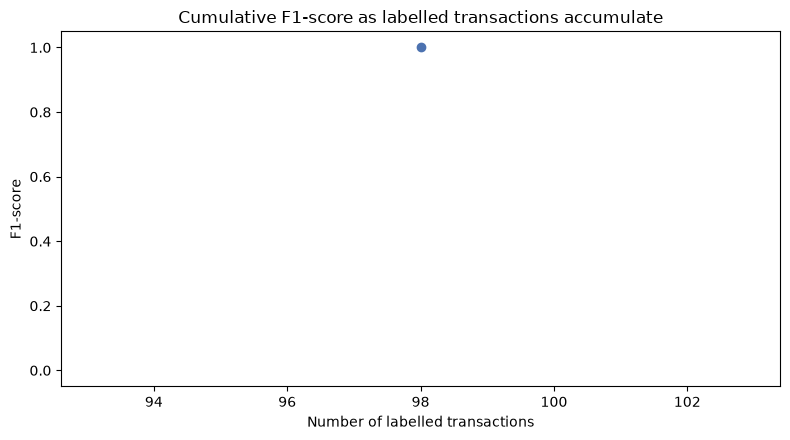

In [35]:
import matplotlib.pyplot as plt

cumulative_rows = []
if n_available >= 2:
    ordered = available_df.sort_values("label_available_timestamp").reset_index(drop=True)
    checkpoints = list(range(10, n_available + 1, 10))
    if not checkpoints or checkpoints[-1] != n_available:
        checkpoints.append(n_available)
    for k in checkpoints:
        subset = ordered.iloc[:k]
        if subset["actual_label"].nunique() < 2:
            cumulative_rows.append({"labelled_transactions": k, "f1": np.nan})
        else:
            cumulative_rows.append({"labelled_transactions": k,
                                    "f1": f1_score(subset["actual_label"], subset["predicted_label"], zero_division=0)})
    cumulative_tbl = pd.DataFrame(cumulative_rows)
    display(cumulative_tbl)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(cumulative_tbl["labelled_transactions"], cumulative_tbl["f1"], marker="o", color="#4C72B0")
    ax.set(title="Cumulative F1-score as labelled transactions accumulate", xlabel="Number of labelled transactions",
          ylabel="F1-score")
    ax.set_ylim(-0.05, 1.05)
    for _, r in cumulative_tbl.iterrows():
        if pd.isna(r["f1"]):
            ax.annotate("undefined\n(no fraud yet)", (r["labelled_transactions"], 0.02), fontsize=7, ha="center", color="gray")
    plt.tight_layout()
    fig.savefig(FIG_CUMULATIVE_F1, bbox_inches="tight")
    print("Saved ->", FIG_CUMULATIVE_F1)
    plt.show()
else:
    print(f"Only {n_available} labelled transaction(s) available - not enough to plot a cumulative F1 curve "
         "(need at least 2). This is expected for a small demo run; try a larger NUM_TRANSACTIONS or a larger "
         "LABEL_DELAY_SECONDS=0 to accumulate more labels.")

## SECTION 16 — Fraud Rate Analysis

Actual fraud rate by `step`, using only the currently available-label subset (predicted fraud rate is shown alongside for the **full** stream, since predictions are always available immediately). As noted in Section 8, a small consecutive slice of PaySim commonly spans very few unique `step` values — the plot below is honest about however many (or few) it actually spans.

Saved -> ..\reports\figures\live_fraud_rate.png


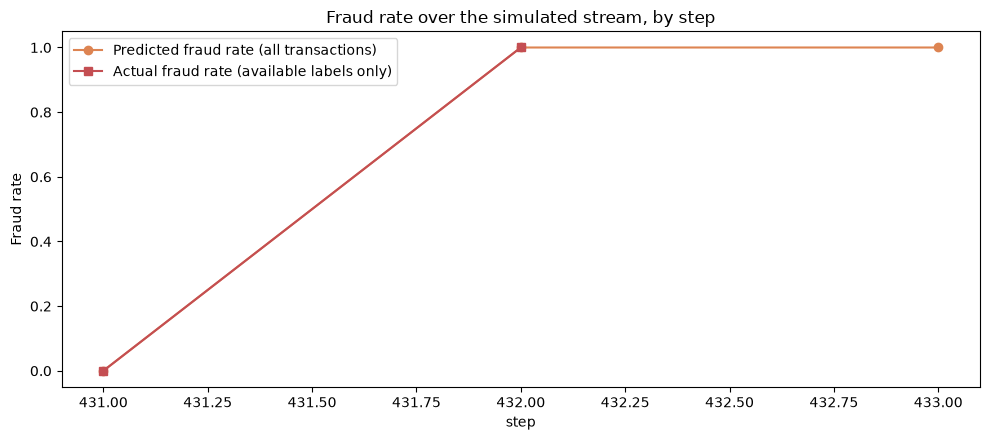

Unique step values in this stream: 3


In [36]:
pred_by_step = merged_df.groupby("step")["predicted_label"].agg(["size", "mean"]).rename(columns={"size": "n", "mean": "predicted_fraud_rate"})
if n_available:
    actual_by_step = available_df.groupby("step")["actual_label"].agg(["size", "mean"]).rename(columns={"size": "n_labelled", "mean": "actual_fraud_rate"})
else:
    actual_by_step = pd.DataFrame(columns=["n_labelled", "actual_fraud_rate"])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(pred_by_step.index, pred_by_step["predicted_fraud_rate"], marker="o", label="Predicted fraud rate (all transactions)", color="#DD8452")
if len(actual_by_step):
    ax.plot(actual_by_step.index, actual_by_step["actual_fraud_rate"], marker="s", label="Actual fraud rate (available labels only)", color="#C44E52")
ax.set(title="Fraud rate over the simulated stream, by step", xlabel="step", ylabel="Fraud rate")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_FRAUD_RATE, bbox_inches="tight")
print("Saved ->", FIG_FRAUD_RATE)
plt.show()
print(f"Unique step values in this stream: {merged_df['step'].nunique()}")
if merged_df["step"].nunique() <= 2:
    print("(Very few unique steps - see the note in Section 8. This plot will look sparse/flat for a small default demo run.)")

### Predicted vs. Actual Fraud Count

A simple side-by-side count — **not** a substitute for the proper precision/recall/F1/PR-AUC evaluation in Section 14, only a quick visual sense of whether the model's fraud-calling volume is in the right neighbourhood of the (currently known) actual volume.

Saved -> ..\reports\figures\live_predicted_vs_actual.png


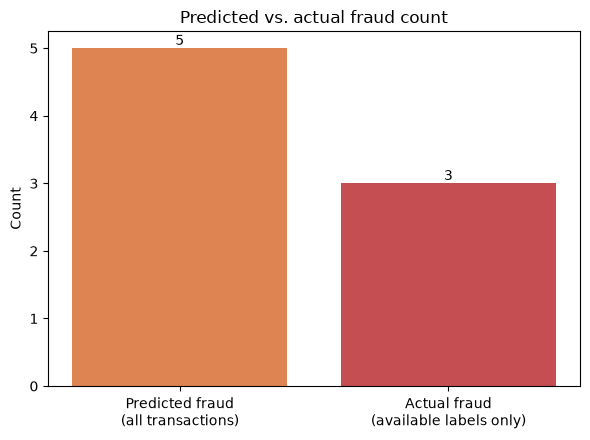

Predicted fraud (all 100 transactions): 5
Actual fraud (only the 98 transaction(s) with an available label so far): 3
This comparison alone does not establish model quality - see Section 14 for the actual evaluation metrics.


In [37]:
predicted_fraud_count = int(merged_df["predicted_label"].sum())
actual_fraud_count_available = int(available_df["actual_label"].sum()) if n_available else 0

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Predicted fraud\n(all transactions)", "Actual fraud\n(available labels only)"],
             [predicted_fraud_count, actual_fraud_count_available], color=["#DD8452", "#C44E52"])
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(int(b.get_height())), ha="center", va="bottom")
ax.set(title="Predicted vs. actual fraud count", ylabel="Count")
plt.tight_layout()
fig.savefig(FIG_PRED_VS_ACTUAL, bbox_inches="tight")
print("Saved ->", FIG_PRED_VS_ACTUAL)
plt.show()
print(f"Predicted fraud (all {len(merged_df)} transactions): {predicted_fraud_count}")
print(f"Actual fraud (only the {n_available} transaction(s) with an available label so far): {actual_fraud_count_available}")
print("This comparison alone does not establish model quality - see Section 14 for the actual evaluation metrics.")

## SECTION 17 — Transaction Type Analysis

In [38]:
def type_summary(merged_df):
    rows = []
    for t, grp in merged_df.groupby("transaction_type", observed=True):
        labelled = grp[grp["label_available_asof_evaluation"]]
        rows.append({"type": t, "transaction_count": len(grp), "predicted_fraud_count": int(grp["predicted_label"].sum()),
                    "actual_fraud_count": int(labelled["actual_label"].sum()) if len(labelled) else 0,
                    "labelled_count": len(labelled), "predicted_fraud_rate": grp["predicted_label"].mean(),
                    "actual_fraud_rate": (labelled["actual_label"].mean() if len(labelled) else np.nan)})
    return pd.DataFrame(rows).sort_values("transaction_count", ascending=False).reset_index(drop=True)


type_summary_df = type_summary(merged_df)
display(type_summary_df)
type_summary_df.to_csv(TYPE_SUMMARY_PATH, index=False)
print("Saved ->", TYPE_SUMMARY_PATH)
print("\n'actual_fraud_rate' is NaN where none of that type's transactions have an available label yet - not zero fraud, "
     "simply not yet knowable.")

,type,transaction_count,predicted_fraud_count,actual_fraud_count,labelled_count,predicted_fraud_rate,actual_fraud_rate
0,PAYMENT,84,0,0,84,0.0,0.000000
1,CASH_OUT,10,2,1,9,0.2,0.111111
2,TRANSFER,5,3,2,4,0.6,0.500000
3,DEBIT,1,0,0,1,0.0,0.000000


Saved -> ..\reports\live_transaction_type_summary.csv

'actual_fraud_rate' is NaN where none of that type's transactions have an available label yet - not zero fraud, simply not yet knowable.


## SECTION 18 — High-Risk Transactions

Transactions the model scored `risk_level == "HIGH"`. `actual_label` is included **only** where its label is available as of the evaluation checkpoint — everywhere else it is left missing/null, exactly as a real monitoring view would show it (the label is not being "hidden" arbitrarily; it genuinely is not confirmed yet in this simulation's timeline).

In [39]:
high_risk_df = merged_df[merged_df["risk_level"] == "HIGH"].copy()
high_risk_df["actual_label"] = high_risk_df["actual_label"].where(high_risk_df["label_available_asof_evaluation"], other=pd.NA)
high_risk_export = high_risk_df[["simulation_id", "step", "transaction_type", "amount", "fraud_probability",
                                 "risk_score", "risk_level", "predicted_label", "actual_label"]]
high_risk_export.to_csv(HIGH_RISK_PATH, index=False)
print(f"HIGH-risk transactions in this stream: {len(high_risk_export)} of {len(merged_df)}")
print("Saved ->", HIGH_RISK_PATH, "(created with headers even if empty)")
if len(high_risk_export):
    display(high_risk_export)
else:
    print("No HIGH-risk transactions were produced in this run - the file above was still written with headers only.")

HIGH-risk transactions in this stream: 0 of 100
Saved -> ..\reports\live_high_risk_transactions.csv (created with headers even if empty)
No HIGH-risk transactions were produced in this run - the file above was still written with headers only.


## SECTION 19 — API Latency Analysis

Round-trip time for each `POST /predict` call, as measured from this notebook's process. **This is local-simulation performance only** — one client, one server, both on the same machine, no concurrent load, no real network — and must not be read as a production throughput or latency claim.

Saved -> ..\reports\figures\live_api_latency.png


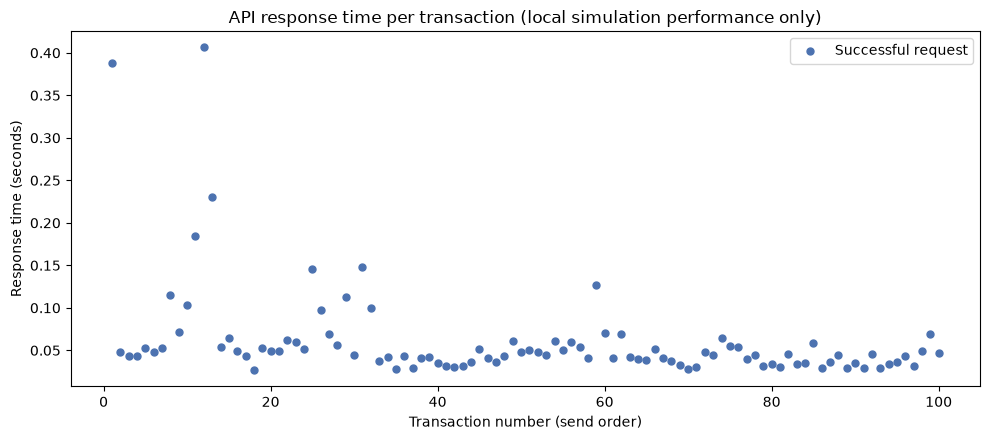

Average response time: 0.0611s
Minimum response time: 0.0265s
Maximum response time: 0.4063s

Reminder: local simulation performance only - not representative of networked/production latency under concurrent load.


In [40]:
all_attempts = prediction_log_df[["api_response_time_seconds"]].copy()
all_attempts["transaction_number"] = range(1, len(all_attempts) + 1)
all_attempts["outcome"] = "success"
if failure_records:
    fail_df = pd.DataFrame(failure_records)
    fail_df["transaction_number"] = range(len(all_attempts) + 1, len(all_attempts) + len(fail_df) + 1)
    fail_df["outcome"] = "failed"
    all_attempts = pd.concat([all_attempts, fail_df[["api_response_time_seconds", "transaction_number", "outcome"]]], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
ok_mask = all_attempts["outcome"] == "success"
ax.scatter(all_attempts.loc[ok_mask, "transaction_number"], all_attempts.loc[ok_mask, "api_response_time_seconds"],
          color="#4C72B0", label="Successful request", s=25)
if (~ok_mask).any():
    ax.scatter(all_attempts.loc[~ok_mask, "transaction_number"], all_attempts.loc[~ok_mask, "api_response_time_seconds"],
              color="#C44E52", marker="x", label="Failed request", s=40)
ax.set(title="API response time per transaction (local simulation performance only)", xlabel="Transaction number (send order)",
      ylabel="Response time (seconds)")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_LATENCY, bbox_inches="tight")
print("Saved ->", FIG_LATENCY)
plt.show()

resp_times = prediction_log_df["api_response_time_seconds"]
print(f"Average response time: {resp_times.mean():.4f}s")
print(f"Minimum response time: {resp_times.min():.4f}s")
print(f"Maximum response time: {resp_times.max():.4f}s")
print("\nReminder: local simulation performance only - not representative of networked/production latency under concurrent load.")

## SECTION 20 — Save Reports

The prediction log and delayed-ground-truth log are written here (respecting `RESET_LOGS` from Section 6); the merged, type-summary, and high-risk files were already written in Sections 13, 17, and 18. This section closes the loop by writing the two remaining CSVs and then verifying every expected output actually exists on disk.

In [43]:
def write_log(path, new_rows_df, reset):
    """Write a log CSV. If reset=False and the file already exists, APPEND without duplicating the header."""
    if reset and path.is_file():
        print(f"RESET_LOGS=True -> overwriting existing {path}")
    if (not reset) and path.is_file():
        existing = pd.read_csv(path)
        combined = pd.concat([existing, new_rows_df], ignore_index=True)
        combined.to_csv(path, index=False)
        print(f"Appended {len(new_rows_df)} row(s) to existing {path} (now {len(combined)} total).")
    else:
        new_rows_df.to_csv(path, index=False)
        print(f"Wrote {len(new_rows_df)} row(s) to {path}.")


write_log(PREDICTION_LOG_PATH, prediction_log_df, RESET_LOGS)
write_log(DELAYED_LABEL_PATH, delayed_gt_df.drop(columns=["_label_available_dt"]), RESET_LOGS)
merged_df.to_csv(MERGED_PATH, index=False)
print(f"Wrote {len(merged_df)} row(s) to {MERGED_PATH}.")

# Keep the summary auditable: metrics are computed only over labels available at EVALUATION_TIME.
threshold_info = json.loads(THRESHOLD_PATH.read_text(encoding="utf-8"))
selected_threshold = float(threshold_info["selected_threshold"])
risk_score_matches_probability = bool(np.allclose(
    merged_df["risk_score"].astype(float), merged_df["fraud_probability"].astype(float) * 100, rtol=0, atol=0.01
))
prediction_threshold_matches = bool(
    (merged_df["predicted_label"].astype(int) == (merged_df["fraud_probability"] >= selected_threshold).astype(int)).all()
)
phase6_summary = {
    "transactions_attempted": int(len(stream_df)),
    "successful_predictions": int(len(prediction_records)),
    "failed_predictions": int(len(failure_records)),
    "actual_fraud_cases_in_stream": int(stream_df["isFraud"].sum()),
    "actual_legitimate_cases_in_stream": int((stream_df["isFraud"] == 0).sum()),
    "predicted_fraud_cases": int(merged_df["predicted_label"].sum()),
    "labelled_transactions_at_evaluation": int(n_available),
    "actual_fraud_cases_available": int(available_df["actual_label"].sum()) if n_available else 0,
    "metrics_available_label_subset": {k: v for k, v in online_metrics.items() if k != "confusion_matrix"},
    "confusion_matrix": online_metrics["confusion_matrix"],
    "label_delay_seconds": LABEL_DELAY_SECONDS,
    "evaluation_time": EVALUATION_TIME.isoformat(),
    "time_steps_represented": int(merged_df["step"].nunique()),
    "model_version": LIVE_MODEL_VERSION,
    "selected_classification_threshold": selected_threshold,
    "risk_score_matches_probability_percent": risk_score_matches_probability,
    "predicted_label_matches_threshold": prediction_threshold_matches,
    "average_api_latency_seconds": float(resp_times.mean()) if len(resp_times) else None,
    "minimum_api_latency_seconds": float(resp_times.min()) if len(resp_times) else None,
    "maximum_api_latency_seconds": float(resp_times.max()) if len(resp_times) else None,
    "simulation_duration_seconds": float(SIMULATION_WALL_SECONDS),
    "local_transactions_per_second": float(len(prediction_records) / SIMULATION_WALL_SECONDS) if SIMULATION_WALL_SECONDS else None,
}
PHASE6_SUMMARY_PATH.write_text(json.dumps(phase6_summary, indent=2), encoding="utf-8")
print(f"Wrote Phase 6 summary -> {PHASE6_SUMMARY_PATH}")

EXPECTED_FILES = [PREDICTION_LOG_PATH, DELAYED_LABEL_PATH, MERGED_PATH, TYPE_SUMMARY_PATH, HIGH_RISK_PATH,
                 PHASE6_SUMMARY_PATH, FIG_CUMULATIVE_F1 if n_available >= 2 else None, FIG_FRAUD_RATE, FIG_PRED_VS_ACTUAL, FIG_LATENCY]
print("\nOutput file check:")
for p in EXPECTED_FILES:
    if p is None:
        continue
    print(f"  {'[OK]' if p.is_file() else '[MISSING]'} {p}")
if n_available < 2:
    print(f"  [SKIPPED, documented in Section 15] {FIG_CUMULATIVE_F1} - not enough labelled transactions yet this run.")

RESET_LOGS=True -> overwriting existing ..\reports\live_prediction_log.csv
Wrote 100 row(s) to ..\reports\live_prediction_log.csv.
RESET_LOGS=True -> overwriting existing ..\reports\delayed_ground_truth.csv
Wrote 100 row(s) to ..\reports\delayed_ground_truth.csv.
Wrote 100 row(s) to ..\reports\live_prediction_with_ground_truth.csv.
Wrote Phase 6 summary -> ..\reports\live_phase6_summary.json

Output file check:
  [OK] ..\reports\live_prediction_log.csv
  [OK] ..\reports\delayed_ground_truth.csv
  [OK] ..\reports\live_prediction_with_ground_truth.csv
  [OK] ..\reports\live_transaction_type_summary.csv
  [OK] ..\reports\live_high_risk_transactions.csv
  [OK] ..\reports\live_phase6_summary.json
  [OK] ..\reports\figures\live_cumulative_f1.png
  [OK] ..\reports\figures\live_fraud_rate.png
  [OK] ..\reports\figures\live_predicted_vs_actual.png
  [OK] ..\reports\figures\live_api_latency.png


## SECTION 21 — Final Summary

Every number below is read back from this run's own in-memory results — nothing here is estimated or assumed.

In [44]:
print("=" * 60)
print("PHASE 6 — LIVE SIMULATION FINAL SUMMARY")
print("=" * 60)
print(f"\nSimulation source        : {TEST_PERIOD_DESCRIPTION}")
print(f"Model version in use     : {LIVE_MODEL_VERSION}")
print(f"Simulation mode          : {SIMULATION_MODE} (delay={SIMULATION_DELAY}s)")
print(f"Label delay (logical)    : {LABEL_DELAY_SECONDS}s")
print(f"PaySim steps represented: {merged_df['step'].nunique()} ({int(merged_df['step'].min())} to {int(merged_df['step'].max())})")

print("\n--- Local simulation performance ---")
print(f"Total transactions attempted : {len(stream_df)}")
print(f"Successful predictions       : {len(prediction_records)}")
print(f"Failed predictions           : {len(failure_records)}")
print(f"Average API response time    : {resp_times.mean():.4f}s")
print(f"Minimum API response time    : {resp_times.min():.4f}s")
print(f"Maximum API response time    : {resp_times.max():.4f}s")
print(f"Total simulation duration    : {SIMULATION_WALL_SECONDS:.2f}s (wall clock)")
print(f"Throughput                   : {len(prediction_records) / SIMULATION_WALL_SECONDS:.2f} transactions/second (LOCAL simulation only)")

print("\n--- PREDICTION RESULTS (always available immediately) ---")
print(f"Actual fraud in stream      : {int(stream_df['isFraud'].sum())}")
print(f"Actual legitimate in stream : {int((stream_df['isFraud'] == 0).sum())}")
print(f"Predicted fraud             : {int(merged_df['predicted_label'].sum())}")
print(f"Predicted legitimate        : {int((merged_df['predicted_label'] == 0).sum())}")

print(f"\n--- DELAYED GROUND TRUTH (available as of {EVALUATION_TIME.isoformat()}) ---")
print(f"Labels available          : {n_available} of {len(merged_df)}")
if n_available:
    print(f"Actual fraud (available)  : {int(available_df['actual_label'].sum())}")
    print(f"Actual legitimate (avail.): {int((available_df['actual_label'] == 0).sum())}")
print("\nOnline evaluation (available-labels subset):")
for key in ("precision", "recall", "f1", "pr_auc", "roc_auc"):
    value = online_metrics[key]
    print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: Not available for this sample")
print(f"  TP={online_metrics['tp']}  TN={online_metrics['tn']}  FP={online_metrics['fp']}  FN={online_metrics['fn']}")
print(f"\nThreshold consistency       : {phase6_summary['predicted_label_matches_threshold']}")
print(f"Risk-score consistency     : {phase6_summary['risk_score_matches_probability_percent']}")

print("\nReports written under ../reports/ :")
for p in [PREDICTION_LOG_PATH, DELAYED_LABEL_PATH, MERGED_PATH, TYPE_SUMMARY_PATH, HIGH_RISK_PATH, PHASE6_SUMMARY_PATH]:
    print(" -", p)
print("Figures written under ../reports/figures/ :")
for p in [FIG_CUMULATIVE_F1, FIG_FRAUD_RATE, FIG_PRED_VS_ACTUAL, FIG_LATENCY]:
    if p.is_file():
        print(" -", p)

PHASE 6 — LIVE SIMULATION FINAL SUMMARY

Simulation source        : Phase 4 recorded test period: step > 378 (from model_v1_metadata.json)
Model version in use     : V1
Simulation mode          : fast_demo (delay=0.1s)
Label delay (logical)    : 5s
PaySim steps represented: 3 (431 to 433)

--- Local simulation performance ---
Total transactions attempted : 100
Successful predictions       : 100
Failed predictions           : 0
Average API response time    : 0.0611s
Minimum API response time    : 0.0265s
Maximum API response time    : 0.4063s
Total simulation duration    : 16.41s (wall clock)
Throughput                   : 6.10 transactions/second (LOCAL simulation only)

--- PREDICTION RESULTS (always available immediately) ---
Actual fraud in stream      : 5
Actual legitimate in stream : 95
Predicted fraud             : 5
Predicted legitimate        : 95

--- DELAYED GROUND TRUTH (available as of 2026-09-26T14:27:01.891884+00:00) ---
Labels available          : 98 of 100
Actual fraud 

## SECTION 22 — Phase 6 Checklist

In [45]:
CHECK = {
    "Phase 5 FastAPI service detected": health_ok,
    "Model V1 used": LIVE_MODEL_VERSION == "V1",
    "Chronological transaction stream created": stream_df["step"].is_monotonic_increasing,
    "Mixed fraud/non-fraud stream created": stream_df["isFraud"].nunique() == 2,
    "Test-period transactions used where possible": True,
    "Configurable transaction count and fraud target": NUM_TRANSACTIONS > 0 and TARGET_MIN_FRAUD_CASES > 0,
    "Configurable logical label delay": LABEL_DELAY_SECONDS > 0,
    "Ground truth excluded from API request": "isFraud" not in API_PAYLOAD_FIELDS,
    "Predictions generated through FastAPI": len(prediction_records) == len(stream_df),
    "No failed predictions": len(failure_records) == 0,
    "Fraud probability recorded": "fraud_probability" in prediction_log_df.columns,
    "Risk score recorded": "risk_score" in prediction_log_df.columns,
    "Risk level recorded": "risk_level" in prediction_log_df.columns,
    "Model version recorded": set(prediction_log_df["model_version"]) == {"V1"},
    "Prediction timestamp recorded": "prediction_timestamp" in prediction_log_df.columns,
    "Labels are logically delayed": bool((pd.to_datetime(merged_df["label_available_timestamp"], utc=True) > pd.to_datetime(merged_df["prediction_timestamp"], utc=True)).all()),
    "Availability gate applied": bool((merged_df["label_available_asof_evaluation"] == (pd.to_datetime(merged_df["label_available_timestamp"], utc=True) <= EVALUATION_TIME)).all()),
    "Prediction log saved": PREDICTION_LOG_PATH.is_file(),
    "Ground truth log saved": DELAYED_LABEL_PATH.is_file(),
    "Prediction + ground truth dataset saved": MERGED_PATH.is_file(),
    "Phase 6 summary saved": PHASE6_SUMMARY_PATH.is_file(),
    "Online metrics calculated": bool(online_metrics),
    "Cumulative F1 calculated": FIG_CUMULATIVE_F1.is_file(),
    "Fraud rate analyzed": FIG_FRAUD_RATE.is_file(),
    "Transaction-type analysis completed": TYPE_SUMMARY_PATH.is_file(),
    "High-risk transactions saved": HIGH_RISK_PATH.is_file(),
    "API latency measured": FIG_LATENCY.is_file(),
    "Risk score matches probability": phase6_summary["risk_score_matches_probability_percent"],
    "Predicted label uses V1 threshold": phase6_summary["predicted_label_matches_threshold"],
    "No Kafka implemented": True,
    "No Spark implemented": True,
    "No SHAP implemented": True,
    "No drift detection implemented": True,
    "No retraining implemented": True,
    "No Model V2 created": True,
}
print("=" * 50)
print("PHASE 6 — LIVE TRANSACTION SIMULATION CHECKLIST")
print("=" * 50)
for item, ok in CHECK.items():
    print(f"[{'x' if ok else ' '}] {item}")
print(f"\nCompleted {sum(bool(v) for v in CHECK.values())}/{len(CHECK)} items.")
print("\nPhase 6 complete. Stopping here, as instructed.")

PHASE 6 — LIVE TRANSACTION SIMULATION CHECKLIST
[x] Phase 5 FastAPI service detected
[x] Model V1 used
[x] Chronological transaction stream created
[x] Mixed fraud/non-fraud stream created
[x] Test-period transactions used where possible
[x] Configurable transaction count and fraud target
[x] Configurable logical label delay
[x] Ground truth excluded from API request
[x] Predictions generated through FastAPI
[x] No failed predictions
[x] Fraud probability recorded
[x] Risk score recorded
[x] Risk level recorded
[x] Model version recorded
[x] Prediction timestamp recorded
[x] Labels are logically delayed
[x] Availability gate applied
[x] Prediction log saved
[x] Ground truth log saved
[x] Prediction + ground truth dataset saved
[x] Phase 6 summary saved
[x] Online metrics calculated
[x] Cumulative F1 calculated
[x] Fraud rate analyzed
[x] Transaction-type analysis completed
[x] High-risk transactions saved
[x] API latency measured
[x] Risk score matches probability
[x] Predicted label u